### **ATTRIBUTES OF AN AI AGENT**

- Autonomy (it can be controlled using permission scope, human-in-the-loop, override controls, guardrails, etc)
- Goal Oriented
- Planning and Reasoning
- Adaptability

### **Langchain VS Langgraph**

- Workflow vs agentic system
- Loops and conditional jumps
- State management
- Event driven execution
- Fault tolerance
- HITL
- Nested Workflows (subgraphs)
- Observability (langsmith)

### **CORE CONCEPTS IN LANGGRAPH**
#### **LLM workflows**: step by step process by which complex tasks can be achieved


##### Common Workflows
- Prompt Chaining
- Routing
- Parallelisation
- Orchestrator worker (subtyoe of parallel, in this we dont know before-hand what exact tasks will be performed)
- Evaluator optimizer

#### **Graphs, nodes and edges**: these are components in langgraph

#### **Agent-State**: used to keep track of required evolving data, uses set of key-value pair for creating state
- Accessible to al nodes
- Mutable by all available nodes individually

#### **Reducers**: it defined how the shared state will be updated by the nodes based on what is required for the application

### **Starting the code part**
#### **Sequential workflows**

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [ ]:
class BMIstate(TypedDict):
    height_m: float
    weight_kg: float
    bmi:float

In [ ]:
def calculate_bmi(state: BMIstate) -> BMIstate:
    state['bmi'] = round(state['weight_kg']/(state['height_m']**2), 2)

    return state

In [ ]:
graph = StateGraph(BMIstate)

In [ ]:
graph.add_node("calculate_bmi", calculate_bmi)

In [ ]:
graph.add_edge(START, "calculate_bmi")
graph.add_edge("calculate_bmi", END)

In [ ]:
workflow = graph.compile()

In [ ]:
workflow.invoke({"weight_kg": 63, "height_m":1.75})

{'height_m': 1.75, 'weight_kg': 63, 'bmi': 20.57}

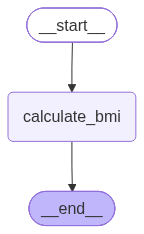

In [ ]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

#### **Parallel workflows**

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [ ]:
class batsPerson(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int

    sr: float
    bpb: float
    bp: float
    summary: str

In [ ]:
def calculate_sr(state: batsPerson):
    
    sr = (state['runs']/state['balls'])*100

    return {"sr": sr}

In [ ]:
def calculate_bpb(state: batsPerson):

    bpb = (state["fours"]+state["sixes"])/state["balls"]

    return {"bpb": bpb}

In [ ]:
def calculate_bp(state: batsPerson):

    bp = ((state["fours"]*4)+(state["sixes"]*6)/state["runs"])*100

    return {"bp":bp}

In [ ]:
def summary(state: batsPerson):

    state["summary"] = f'''strike rate: {state['sr']}
balls per boundary: {state["bpb"]}
boundary percentage: {state["bp"]}'''

    return state

In [ ]:
graph = StateGraph(batsPerson)

In [ ]:
graph.add_node("calculate_sr", calculate_sr)
graph.add_node("calculate_bpb", calculate_bpb)
graph.add_node("calculate_bp", calculate_bp)
graph.add_node("summary", summary)

In [ ]:
graph.add_edge(START, "calculate_sr")
graph.add_edge(START, "calculate_bpb")
graph.add_edge(START, "calculate_bp")

In [ ]:
graph.add_edge("calculate_sr", "summary")
graph.add_edge("calculate_bpb", "summary")
graph.add_edge("calculate_bp", "summary")

In [ ]:
graph.add_edge("summary", END)

In [ ]:
workflow = graph.compile()

In [ ]:
initial_state = {
    "runs": 264,
    "balls": 164,
    "fours": 21,
    "sixes": 15,
}

In [ ]:
workflow.invoke(initial_state)

{'runs': 264,
 'balls': 164,
 'fours': 21,
 'sixes': 15,
 'sr': 160.97560975609758,
 'bpb': 0.21951219512195122,
 'bp': 8434.09090909091,
 'summary': 'strike rate: 160.97560975609758\nballs per boundary: 0.21951219512195122\nboundary percentage: 8434.09090909091'}

In [1]:
def model_setup():
    from dotenv import load_dotenv
    load_dotenv()

    from langchain_google_genai import ChatGoogleGenerativeAI
    model = ChatGoogleGenerativeAI(model="gemini-3.5-flash")

    return model

- **Reducers usage**: suppose we want to constraint how an variable in agentstate would be updated by differnt nodes, for example we want to merge the output form three different nodes into one single list then we can do it using reducers

In [34]:
from pydantic import BaseModel, Field
from typing import TypedDict, Annotated
import operator

- in the list created below when the different nodes will return a list then all the list would be merged into one singular list and stored in the state variable of `list_variable`, eg: three nodes returned `[8], [5], [7]` then the `list_variable` would become `[8, 5, 7]`

In [35]:
class state(BaseModel):
    list_variable: Annotated[list[int], operator.add]

#### **Conditional Workflows**

In [22]:
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field
from typing import TypedDict, Literal

In [23]:
class sentimentSchema(TypedDict):
    sentiment: Literal["positive", "negative"] = Field(description="sentiment of the review")

class dignosisSchema(TypedDict):
    issue_type: Literal["UX", "performance", "bug", "support", "other"] = Field(description="issue type mentioned in the review")
    tone: Literal["angry", "frustrated", "calm", "disappointed"] = Field(description="tone of the review")
    urgency: Literal["low", "medium", "high"] = Field(description="urgeny of the review")

In [24]:
class reviewState(BaseModel):

    review: str
    sentiment: Literal["positive", "negative"] | None = None
    diagnosis: dict = Field(default_factory=dict)
    response: str = ""

In [25]:
model = model_setup()
sentiment_model = model.with_structured_output(sentimentSchema)
diagnosis_model = model.with_structured_output(dignosisSchema)

In [41]:
def find_sentiment(state: reviewState):

    prompt = f"""Find out the sentiment of the following review": {state.review}"""
    sentiment = sentiment_model.invoke(prompt)["sentiment"]

    return {"sentiment": sentiment}

def check_sentiment(state:reviewState) -> Literal["positive_sentiment", "run_diagnosis"]:

    if state.sentiment == "positive":
        return "positive_response"
    else:
        return "run_diagnosis"

def run_diagnosis(state:reviewState):

    prompt = f"""Diagnose the negative review": {state.review}, return the issue type, tone, urgency"""
    diagnosis = diagnosis_model.invoke(prompt)

    return {"diagnosis": diagnosis}

def positive_sentiment(state:reviewState):

    prompt = f"""Wrtie a warm thank you message for the user in reponse to the review {state.review}"""
    response = model.invoke(prompt)

    return {"response": response}

def negative_sentiment(state:reviewState):

    prompt = f"""You are an support assistant.
    The user has a {state.diagnosis["issue_type"]}, sounded {state.diagnosis["tone"]}, and marked the urgency as {state.diagnosis["urgency"]}, write and empathatic and helpfule resolution message"""
    response = model.invoke(prompt)

    return {"response": response.content[0]["text"]}

In [42]:
graph = StateGraph(reviewState)

In [43]:
graph.add_node("find_sentiment", find_sentiment)
graph.add_node("run_diagnosis", run_diagnosis)
graph.add_node("negative_sentiment", negative_sentiment)
graph.add_node("positive_sentiment", positive_sentiment)

graph.add_edge(START, "find_sentiment")
graph.add_conditional_edges("find_sentiment", check_sentiment)
graph.add_edge("run_diagnosis", "negative_sentiment")
graph.add_edge("negative_sentiment", END)
graph.add_edge("positive_sentiment", END)

conditional_workflow = graph.compile()

In [44]:
initial_state = {"review":"this was a very bad product"}

In [45]:
conditional_workflow.invoke(initial_state)

{'review': 'this was a very bad product',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'bug', 'tone': 'angry', 'urgency': 'medium'},
 'response': "Subject: Sincere apologies – Let's get this sorted out for you right away\n\nHi [User Name],\n\nI completely understand your frustration, and I am so sorry for the trouble you've been experiencing with [mention the issue briefly, e.g., the recent update / the login error]. I know how disruptive this is to your day, and you have every right to be upset. \n\nI want to make this right as quickly as possible. \n\nTo help me get this resolved for you right now, could you please provide a little more detail or a quick screenshot of what you're seeing? *(If you've already tried any troubleshooting steps, let me know so we don't repeat them).*\n\nAs soon as I hear back from you, I will prioritize this on my end and work on a fix. Thank you for your patience while we get this sorted out.\n\nBest regards,\n\n[Your Name]  \nSupport Team"}

In [ ]:
# console.log("Pooja bhabhi meri hoor vargi")

Pooja bhabhi meri hoor vargi


#### **Iterative Workflows**: nothing fancy jsut use edges in the graph to create loops, just keep in mind to avoid infinite loops

#### **Persistance**: saving and restoring the state overtime (every intermediate is also stored)
- checkpoints: there is an checkpoint at the start/before any node (the processing of one node level)
- thread id: id to identify different excutations (persisted state flow) of a workflow

In [2]:
from langgraph.graph import StateGraph, END, START
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict

In [3]:
class jokeState(TypedDict):
    topic: str
    joke: str
    explanation: str

In [4]:
model = model_setup()

In [5]:
import time

def generate_joke(state: jokeState):
    start = time.perf_counter()

    prompt = f"Generate a short joke about {state['topic']}."
    response = model.invoke(prompt)

    print(f"\nJoke call: {time.perf_counter() - start:.2f}s")
    return {"joke": response.content}


def generate_explanation(state: jokeState):
    start = time.perf_counter()

    prompt = f"Briefly explain this joke: {state['joke']}."
    response = model.invoke(prompt)

    print(f"\nExplanation call: {time.perf_counter() - start:.2f}s")
    return {"explanation": response.content}

In [6]:
graph = StateGraph(jokeState)

graph.add_node("generate_joke", generate_joke)
graph.add_node("generate_explanation", generate_explanation)

graph.add_edge(START, "generate_joke")
graph.add_edge("generate_joke", "generate_explanation")
graph.add_edge("generate_explanation", END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

In [7]:
config = {"configurable": {"thread_id": 1}}

In [ ]:
workflow.invoke({"topic": "space"}, config=config)

In [9]:
list(workflow.get_state_history(config=config))

[StateSnapshot(values={'topic': 'space', 'joke': 'Why did the astronaut break up with his girlfriend?\n\nHe needed some space.', 'explanation': 'Here is the explanation of the joke:\n\n**The Joke:** \n*"Why did the astronaut break up with his girlfriend? — He needed some space."*\n\n**The Explanation:**\nThis joke is a **pun** (a play on words) that relies on a double meaning of the word **"space"**:\n\n1. **Literal meaning:** In the context of an astronaut, "space" refers to outer space (the universe beyond Earth). \n2. **Idiomatic meaning:** In the context of a relationship, asking for "some space" is a common phrase meaning a person needs some time apart from their partner to be alone or think. \n\nThe humor comes from the fact that an astronaut literally works in space, making the common relationship cliché take on a hilarious, literal twist.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a8646-778d-6fe9-8002-c242d2ff9ddb'}}, metada

In [37]:
workflow.get_state(config=config)

StateSnapshot(values={'topic': 'space', 'joke': 'How do celebrities stay cool in outer space?\n\nThey use **super-novas**!', 'explanation': 'Here is the explanation of the joke:\n\n**The Joke:**\n> How do celebrities stay cool in outer space?\n> They use **super-novas**!\n\n**The Explanation:**\nThis joke is a pun (a play on words) that relies on two meanings:\n\n1. **"Supernovas" (Astronomy):** In space, a supernova is a powerful and luminous stellar explosion that occurs during the last evolutionary stages of a massive star. \n2. **The Pun (Celebrities + Cooling):** \n   * **"Super"** is a slang term often used to describe extremely famous, high-profile celebrities ("superstars").\n   * **"Novas"** sounds like **"no-vas"** (short for *No-Vas*), suggesting a brand of electric fan or air conditioning unit. \n\nSo, when the joke asks how *super*stars stay cool, the punchline suggests they use "super-novas" (super fans/air conditioners) to beat the heat in outer space!'}, next=(), config

In [39]:
workflow.invoke(None, config=config)    # Re-running the workflow form the point where is left executtion last time 

{'topic': 'space',
 'joke': 'How do celebrities stay cool in outer space?\n\nThey use **super-novas**!',
 'explanation': 'Here is the explanation of the joke:\n\n**The Joke:**\n> How do celebrities stay cool in outer space?\n> They use **super-novas**!\n\n**The Explanation:**\nThis joke is a pun (a play on words) that relies on two meanings:\n\n1. **"Supernovas" (Astronomy):** In space, a supernova is a powerful and luminous stellar explosion that occurs during the last evolutionary stages of a massive star. \n2. **The Pun (Celebrities + Cooling):** \n   * **"Super"** is a slang term often used to describe extremely famous, high-profile celebrities ("superstars").\n   * **"Novas"** sounds like **"no-vas"** (short for *No-Vas*), suggesting a brand of electric fan or air conditioning unit. \n\nSo, when the joke asks how *super*stars stay cool, the punchline suggests they use "super-novas" (super fans/air conditioners) to beat the heat in outer space!'}

In [41]:
workflow.get_state(config={"configurable": {"thread_id": 1, 'checkpoint_id': '1f1a4536-64b3-6387-8000-4fe16b589194'}})

StateSnapshot(values={'topic': 'space'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f1a4536-64b3-6387-8000-4fe16b589194'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-08-30T09:15:53.064128+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a4536-64b0-6cb3-bfff-803f81f0ada7'}}, tasks=(PregelTask(id='0bcfd87b-0c5c-cb11-8acc-55946d73b41c', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': 'How do celebrities stay cool in outer space?\n\nThey use **super-novas**!'}),), interrupts=())

In [42]:
workflow.invoke(None, config={"configurable": {"thread_id": 1, 'checkpoint_id': '1f1a4536-64b3-6387-8000-4fe16b589194'}})   # Re-running form and particular checkpoint using its id

{'topic': 'space',
 'joke': "Why didn't the sun go to college?\n\nBecause it already had a million degrees!",
 'explanation': 'This joke is a play on words (a pun) based on two different meanings of the word **"degrees"**:\n\n1. **Temperature:** The sun is extremely hot, and its temperature is measured in millions of degrees (specifically, about 27 million degrees Fahrenheit at its core).\n2. **Education:** A "degree" is an academic qualification you receive when you graduate from college. \n\nSo, the joke sets up the idea of the sun going to higher education, but the punchline uses its literal, scientific heat to explain that it is already over-qualified!'}

In [43]:
list(workflow.get_state_history(config=config))

[StateSnapshot(values={'topic': 'space', 'joke': "Why didn't the sun go to college?\n\nBecause it already had a million degrees!", 'explanation': 'This joke is a play on words (a pun) based on two different meanings of the word **"degrees"**:\n\n1. **Temperature:** The sun is extremely hot, and its temperature is measured in millions of degrees (specifically, about 27 million degrees Fahrenheit at its core).\n2. **Education:** A "degree" is an academic qualification you receive when you graduate from college. \n\nSo, the joke sets up the idea of the sun going to higher education, but the punchline uses its literal, scientific heat to explain that it is already over-qualified!'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a4569-b349-6308-8003-daba01dd70fa'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-08-30T09:38:50.325274+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkp

In [46]:
workflow.update_state({"configurable": {"thread_id": 1, 'checkpoint_id': '1f1a4536-64b3-6387-8000-4fe16b589194', 'checkpoint_ns': ''}}, {"topic": "dinosaurs"})     # Updateing the values of the state at a particular checkpoint (it forks)

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1a4570-a7e5-6dec-8001-b2d0c6a07b10'}}

#### **Streaming in langgraph**

In [8]:
for message_chunk, metadata in workflow.stream({"topic": "space"}, config=config, stream_mode="messages"):
    content = message_chunk.content

    if isinstance(content, str):
        text = content
    elif isinstance(content, list):
        text = "".join(
            block.get("text", "")
            for block in content
            if isinstance(block, dict)
        )
    else:
        text = ""

    if text:
        print(text, end="", flush=True)

How does the moon cut its hair?

*Eclipse it!*
Joke call: 26.71s
This joke is a pun (wordplay) based on the homophones (words that sound alike):

* **"Eclipse it"** (an astronomical event involving the moon) sounds like **"He clips it"** (meaning to trim or cut hair).
Explanation call: 8.29s
